<a href="https://colab.research.google.com/github/keshavbaviskar33-sudo/AI-Credit-Analyst-Copilot/blob/main/notebooks/02_ratio_engineering_and_baseline_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("utkarshx27/american-companies-bankruptcy-prediction-dataset")

print("Path to dataset files:", path)

100%|██████████| 4.47M/4.47M [00:01<00:00, 3.46MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/utkarshx27/american-companies-bankruptcy-prediction-dataset/versions/3


## Model Comparison — Logistic Regression vs Random Forest

Tested Random Forest as an alternative to the logistic regression baseline, using the
same 5 winsorized ratio features, to see if a more complex model improved recall.

**Attempt 1 — default `class_weight='balanced'`:** TP=0, FN=5, FP=1, recall=0.00.
Despite class weighting, the model predicted "safe" for every single test row,
including all 5 actual failures.

**Why this happened:** class_weight adjusts the training loss/split criterion, but
Random Forest builds many trees from bootstrapped samples of the training data. With
only ~0.8% positive examples, many individual bootstrap samples likely contained very
few or zero failure examples, so trees had no minority-class signal to split on
regardless of reweighting.

**Attempt 2 — `class_weight='balanced_subsample'`:** identical result (TP=0, FN=5,
FP=1). Reweighting per-bootstrap-sample rather than globally made no difference,
confirming the problem isn't the weighting variant — it's a lack of actual minority
examples for trees to learn from.

**Attempt 3 — SMOTE oversampling (training data only):** generated synthetic minority
examples via interpolation, bringing training data from 580 to 51,485 failure examples
(matched to majority class). Applied SMOTE only to X_train/y_train, never to test data.
Result: TP=1, FN=4, FP=513, recall=0.20 — an improvement over the broken Random Forest
attempts, but still well below logistic regression's recall of 0.60.

**Decision:** logistic regression (5 winsorized + scaled features) remains the
strongest model tested. After three separate imbalance-handling strategies with
Random Forest all underperforming it on recall, further model-shopping (e.g. XGBoost)
was deprioritized given time constraints — a converging, well-documented result across
three attempts is stronger evidence than a fourth untested guess.

**Caveat carried forward:** all comparisons are against a test set with only 5 actual
failures, so absolute recall values remain statistically fragile — but the *relative*
ranking between models (logistic regression > Random Forest, regardless of imbalance
strategy) is a more robust finding, since it held consistently across three different
mitigation attempts.

In [2]:
import kagglehub
import pandas as pd
import numpy as np
import os
from scipy.stats.mstats import winsorize

# Load data
path = kagglehub.dataset_download("utkarshx27/american-companies-bankruptcy-prediction-dataset")
df = pd.read_csv(os.path.join(path, "american_bankruptcy.csv"))

# Ratio engine
df['current_ratio'] = df['X1'] / df['X14']
df['debt_to_equity'] = df['X11'] / (df['X10'] - df['X17'])
df['net_profit_margin'] = df['X6'] / df['X16']
df['ebitda_margin'] = df['X4'] / df['X16']
df['retained_earnings_to_assets'] = df['X15'] / df['X10']

# Winsorize all 5 ratios at 1st/99th percentile (both tails)
ratio_cols = ['current_ratio', 'debt_to_equity', 'net_profit_margin',
              'ebitda_margin', 'retained_earnings_to_assets']
for col in ratio_cols:
    df[col] = winsorize(df[col], limits=[0.01, 0.01])

# Target label construction
failure_year = df[df['status_label'] == 'failed'].groupby('company_name')['year'].min()
df['failure_year'] = df['company_name'].map(failure_year)
df['years_until_failure'] = df['failure_year'] - df['year']

# Remove post-failure "zombie" rows
df = df[~(df['years_until_failure'] < 0)]

# Build target
df['target'] = (
    (df['years_until_failure'] >= 0) & (df['years_until_failure'] <= 2)
).astype(int)

# Train/test split
train = df[df['year'] <= 2011]
test = df[df['year'] >= 2015]

# Sanity check
print("Rows after cleaning:", len(df))
print("Target distribution:\n", df['target'].value_counts(normalize=True))

Using Colab cache for faster access to the 'american-companies-bankruptcy-prediction-dataset' dataset.
Rows after cleaning: 74071
Target distribution:
 target
0    0.991778
1    0.008222
Name: proportion, dtype: float64


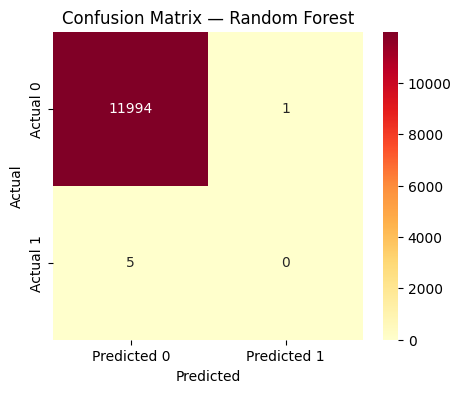

,precision,recall,f1-score,support
0,0.999583,0.999917,0.999750,11995.000000
1,0.000000,0.000000,0.000000,5.000000
accuracy,0.999500,0.999500,0.999500,0.999500
macro avg,0.499792,0.499958,0.499875,12000.000000
weighted avg,0.999167,0.999500,0.999333,12000.000000


In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

X_train, y_train = train[ratio_cols], train['target']
X_test, y_test = test[ratio_cols], test['target']

# Note: no scaling needed for tree-based models — they split on raw thresholds,
# unaffected by feature scale the way logistic regression is
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)
preds_rf = rf_model.predict(X_test)

cm = confusion_matrix(y_test, preds_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['Predicted 0','Predicted 1'],
            yticklabels=['Actual 0','Actual 1'])
plt.title('Confusion Matrix — Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

report_dict = classification_report(y_test, preds_rf, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
display(report_df.style.background_gradient(cmap='YlOrRd', subset=['precision','recall','f1-score']))

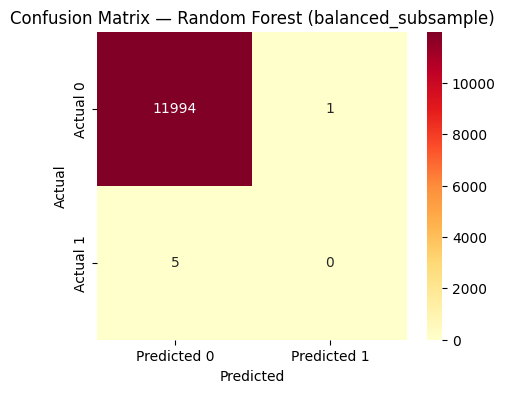

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11995
           1       0.00      0.00      0.00         5

    accuracy                           1.00     12000
   macro avg       0.50      0.50      0.50     12000
weighted avg       1.00      1.00      1.00     12000



In [4]:
rf_model_v2 = RandomForestClassifier(class_weight='balanced_subsample', random_state=42)
rf_model_v2.fit(X_train, y_train)
preds_rf_v2 = rf_model_v2.predict(X_test)

cm = confusion_matrix(y_test, preds_rf_v2)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['Predicted 0','Predicted 1'],
            yticklabels=['Actual 0','Actual 1'])
plt.title('Confusion Matrix — Random Forest (balanced_subsample)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(classification_report(y_test, preds_rf_v2))

In [5]:
!pip install imbalanced-learn

In [6]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_smote.value_counts().to_dict())

rf_model_v3 = RandomForestClassifier(random_state=42)
rf_model_v3.fit(X_train_smote, y_train_smote)
preds_rf_v3 = rf_model_v3.predict(X_test)

print(confusion_matrix(y_test, preds_rf_v3))
print(classification_report(y_test, preds_rf_v3))

Before SMOTE: {0: 51485, 1: 580}
After SMOTE: {0: 51485, 1: 51485}
[[11482   513]
 [    4     1]]
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     11995
           1       0.00      0.20      0.00         5

    accuracy                           0.96     12000
   macro avg       0.50      0.58      0.49     12000
weighted avg       1.00      0.96      0.98     12000

